In [30]:
import os
import numpy as np
import pandas as pd

import librosa

from scipy.stats import skew
from scipy.stats import kurtosis

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
import numpy as np
import librosa
from scipy.stats import skew, kurtosis

def extract_features(file_path):

    y, sr = librosa.load(file_path, sr=8000)

    feature_vector = []

    # =====================================================
    # 1. Time Domain Features (10)
    # =====================================================

    feature_vector.append(np.mean(y))
    feature_vector.append(np.std(y))
    feature_vector.append(np.var(y))
    feature_vector.append(np.sqrt(np.mean(y**2)))        # RMS
    feature_vector.append(np.max(y))
    feature_vector.append(np.min(y))
    feature_vector.append(np.ptp(y))                     # Peak-to-Peak
    feature_vector.append(skew(y))
    feature_vector.append(kurtosis(y))
    feature_vector.append(np.mean(librosa.feature.zero_crossing_rate(y)))

    # =====================================================
    # 2. Frequency Domain Features (10)
    # =====================================================

    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(
    y=y,
    sr=sr,
    fmin=50,
    n_bands=4
    )
    flatness = librosa.feature.spectral_flatness(y=y)

    feature_vector.append(np.mean(centroid))
    feature_vector.append(np.mean(bandwidth))
    feature_vector.append(np.mean(rolloff))
    feature_vector.append(np.mean(contrast))
    feature_vector.append(np.mean(flatness))

    # FFT

    fft = np.abs(np.fft.rfft(y))
    freq = np.fft.rfftfreq(len(y), d=1/sr)

    # Dominant Frequency

    feature_vector.append(freq[np.argmax(fft)])

    # Spectral Entropy

    psd = fft**2
    psd /= np.sum(psd)

    entropy = -np.sum(psd * np.log2(psd + 1e-12))

    feature_vector.append(entropy)

    # Spectral Spread

    spread = np.sqrt(
        np.sum(((freq - np.mean(freq))**2) * fft) / np.sum(fft)
    )

    feature_vector.append(spread)

    # Spectral Flux

    flux = np.mean(np.diff(fft)**2)

    feature_vector.append(flux)

    # Energy

    energy = np.sum(y**2)

    feature_vector.append(energy)

    # =====================================================
    # 3. MFCC Mean (13)
    # =====================================================

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )

    feature_vector.extend(np.mean(mfcc, axis=1))

    # =====================================================
    # 4. MFCC STD (13)
    # =====================================================

    feature_vector.extend(np.std(mfcc, axis=1))

    # =====================================================
    # 5. Delta MFCC (13)
    # =====================================================

    delta = librosa.feature.delta(mfcc)

    feature_vector.extend(np.mean(delta, axis=1))

    # =====================================================
    # 6. Delta-Delta MFCC (13)
    # =====================================================

    delta2 = librosa.feature.delta(
        mfcc,
        order=2
    )

    feature_vector.extend(np.mean(delta2, axis=1))

    # =====================================================
    # 7. Chroma (12)
    # =====================================================

    chroma = librosa.feature.chroma_stft(
    y=y,
    sr=sr,
    n_chroma=12,
    n_fft=1024,
    hop_length=256
    )

    feature_vector.extend(np.mean(chroma, axis=1))

    # =====================================================
    # 8. Tonnetz (6)
    # =====================================================

    harmonic = librosa.effects.harmonic(y)

    tonnetz = librosa.feature.tonnetz(
    y=harmonic,
    sr=sr,
    chroma=librosa.feature.chroma_cqt(
        y=harmonic,
        sr=sr,
        bins_per_octave=12,
        n_octaves=5
    )
    )
    feature_vector.extend(np.mean(tonnetz, axis=1))

    return np.array(feature_vector)

In [32]:
import os
import numpy as np
import pandas as pd

# ==============================
# Dataset Path
# ==============================

Data_path = "/content/drive/MyDrive/Heart_sound"   # Change this

classes = ['AS', 'MR', 'MS', 'MVP', 'Normal']

X = []
y = []

# ==============================
# Extract Features
# ==============================

for label in classes:

    folder = os.path.join(Data_path, label)

    print(f"\nProcessing {label}...")

    for file in os.listdir(folder):

        if file.endswith(".wav"):

            file_path = os.path.join(folder, file)

            try:

                feature_vector = extract_features(file_path)

                X.append(feature_vector)

                y.append(label)

            except Exception as e:

                print(file_path)
                print(e)

X = np.array(X)

y = np.array(y)

print("\nFinished")
print("Feature Matrix Shape :", X.shape)
print("Labels Shape :", y.shape)


Processing AS...

Processing MR...

Processing MS...


/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(



Processing MVP...

Processing Normal...

Finished
Feature Matrix Shape : (1000, 90)
Labels Shape : (1000,)


In [33]:
feature_names = [

# Time-domain (10)
'Mean','Std','Variance','RMS','Maximum','Minimum',
'Peak_to_Peak','Skewness','Kurtosis','ZeroCrossingRate',

# Frequency-domain (10)
'SpectralCentroid',
'SpectralBandwidth',
'SpectralRolloff',
'SpectralContrast',
'SpectralFlatness',
'DominantFrequency',
'SpectralEntropy',
'SpectralSpread',
'SpectralFlux',
'Energy'
]

# MFCC Mean (13)
feature_names += [f"MFCC_Mean_{i}" for i in range(1,14)]

# MFCC STD (13)
feature_names += [f"MFCC_STD_{i}" for i in range(1,14)]

# Delta MFCC (13)
feature_names += [f"Delta_MFCC_{i}" for i in range(1,14)]

# Delta² MFCC (13)
feature_names += [f"Delta2_MFCC_{i}" for i in range(1,14)]

# Chroma (12)
feature_names += [f"Chroma_{i}" for i in range(1,13)]

# Tonnetz (6)
feature_names += [f"Tonnetz_{i}" for i in range(1,7)]

print(len(feature_names))

90


In [34]:
df = pd.DataFrame(X, columns=feature_names)

df["Label"] = y

df.head()

,Mean,Std,Variance,RMS,Maximum,Minimum,Peak_to_Peak,Skewness,Kurtosis,ZeroCrossingRate,...,Chroma_10,Chroma_11,Chroma_12,Tonnetz_1,Tonnetz_2,Tonnetz_3,Tonnetz_4,Tonnetz_5,Tonnetz_6,Label
0,-0.000465,0.073205,0.005359,0.073207,0.379089,-0.462677,0.841766,-0.079176,5.379604,0.221082,...,0.568939,0.482706,0.442314,0.017142,0.013387,0.013224,-0.004587,0.001150,0.013629,AS
1,0.000221,0.126003,0.015877,0.126004,0.559174,-0.531586,1.090759,0.015929,4.450047,0.043894,...,0.421249,0.358585,0.355138,-0.005388,-0.002790,-0.023937,-0.022688,0.004046,0.001374,AS
2,0.000140,0.270559,0.073202,0.270559,0.999969,-1.000000,1.999969,0.145057,4.419405,0.085958,...,0.403228,0.372521,0.386518,0.017189,-0.007566,0.012128,0.041802,0.015770,0.002142,AS
3,0.000227,0.100680,0.010137,0.100681,0.525574,-0.596161,1.121735,0.005024,6.140544,0.098834,...,0.496524,0.490788,0.501186,0.001255,-0.009098,0.037582,-0.016812,-0.014115,-0.011399,AS
4,-0.000292,0.076762,0.005892,0.076762,0.558929,-0.565460,1.124390,-0.079930,14.768934,0.103729,...,0.511472,0.555547,0.573020,0.003389,0.009203,0.004435,-0.006910,-0.000660,-0.012736,AS


In [35]:
print(df.shape)

(1000, 91)


In [36]:
print("Number of features in X:", X.shape[1])
print("Number of feature names:", len(feature_names))

Number of features in X: 90
Number of feature names: 90


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Features and labels
X = df.drop("Label", axis=1)
y = df["Label"]

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(800, 90)
(200, 90)


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [39]:
models = {

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "SVM":
        SVC(
            kernel='rbf',
            probability=True,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "Logistic Regression":
        LogisticRegression(
            max_iter=5000
        ),

    "Naive Bayes":
        GaussianNB()
}

In [40]:
results = []

for name, model in models.items():

    print("="*60)
    print(name)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    precision = precision_score(
        y_test,
        pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        pred,
        average='weighted'
    )

    results.append([
        name,
        acc,
        precision,
        recall,
        f1
    ])

    print("Accuracy :", round(acc,4))
    print("Precision:", round(precision,4))
    print("Recall    :", round(recall,4))
    print("F1 Score  :", round(f1,4))

Random Forest
Accuracy : 0.99
Precision: 0.9905
Recall    : 0.99
F1 Score  : 0.99
Extra Trees
Accuracy : 0.99
Precision: 0.9905
Recall    : 0.99
F1 Score  : 0.99
Gradient Boosting
Accuracy : 0.98
Precision: 0.981
Recall    : 0.98
F1 Score  : 0.9799
SVM
Accuracy : 0.99
Precision: 0.9905
Recall    : 0.99
F1 Score  : 0.99
KNN
Accuracy : 0.965
Precision: 0.9658
Recall    : 0.965
F1 Score  : 0.9647
Logistic Regression
Accuracy : 0.97
Precision: 0.9714
Recall    : 0.97
F1 Score  : 0.9702
Naive Bayes
Accuracy : 0.85
Precision: 0.8506
Recall    : 0.85
F1 Score  : 0.848


In [41]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.990,0.990476,0.990,0.989994
1,Extra Trees,0.990,0.990476,0.990,0.989994
3,SVM,0.990,0.990476,0.990,0.989994
2,Gradient Boosting,0.980,0.980952,0.980,0.979920
5,Logistic Regression,0.970,0.971389,0.970,0.970228
4,KNN,0.965,0.965842,0.965,0.964719
6,Naive Bayes,0.850,0.850572,0.850,0.847969


In [42]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [43]:
best_model = models["Random Forest"]

pred = best_model.predict(X_test)

print(classification_report(
    y_test,
    pred,
    target_names=le.classes_
))


              precision    recall  f1-score   support

          AS       0.95      1.00      0.98        40
          MR       1.00      1.00      1.00        40
          MS       1.00      1.00      1.00        40
         MVP       1.00      0.95      0.97        40
      Normal       1.00      1.00      1.00        40

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



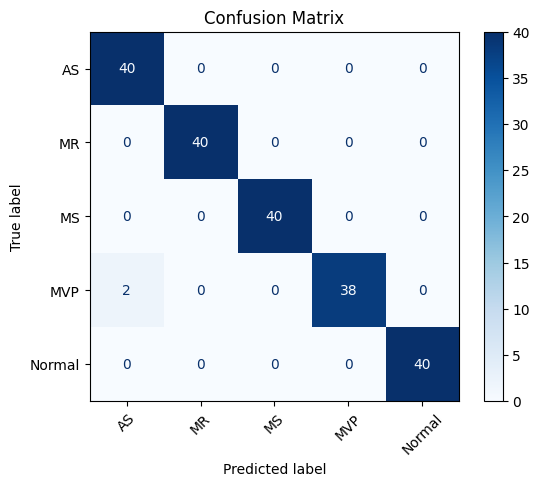

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=le.classes_,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.show()

In [45]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
16,SpectralEntropy,0.057741
27,MFCC_Mean_8,0.057502
29,MFCC_Mean_10,0.048752
47,Delta_MFCC_2,0.046305
28,MFCC_Mean_9,0.045603
46,Delta_MFCC_1,0.043944
33,MFCC_STD_1,0.042658
21,MFCC_Mean_2,0.034583
34,MFCC_STD_2,0.032076
26,MFCC_Mean_7,0.029696


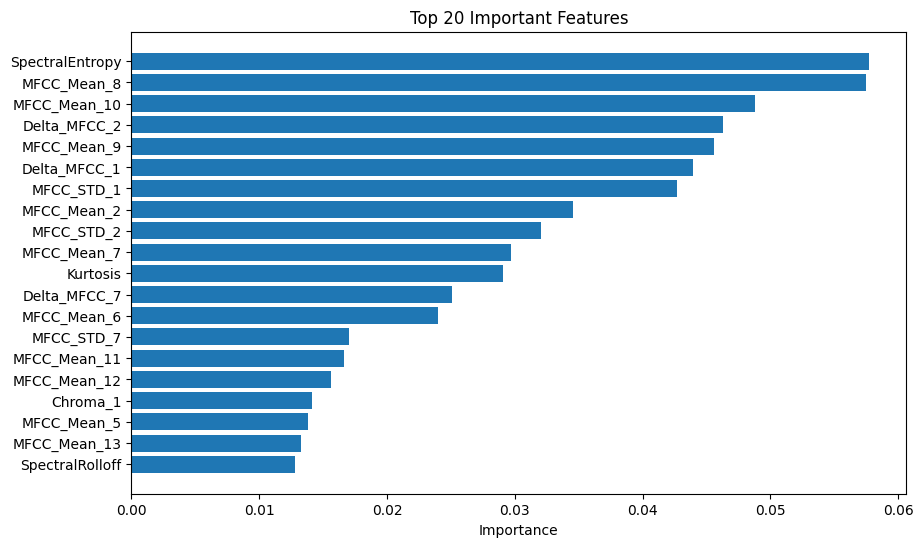

In [46]:
top20 = importance.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 20 Important Features")

plt.show()

In [56]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Fold Accuracies:", scores)
print("Mean Accuracy :", scores.mean())
print("Std :", scores.std())

Fold Accuracies: [0.99 1.   0.99 1.   0.99 1.   0.99 1.   0.99 1.  ]
Mean Accuracy : 0.9949999999999999
Std : 0.0050000000000000044


In [57]:
!pip install openTSNE

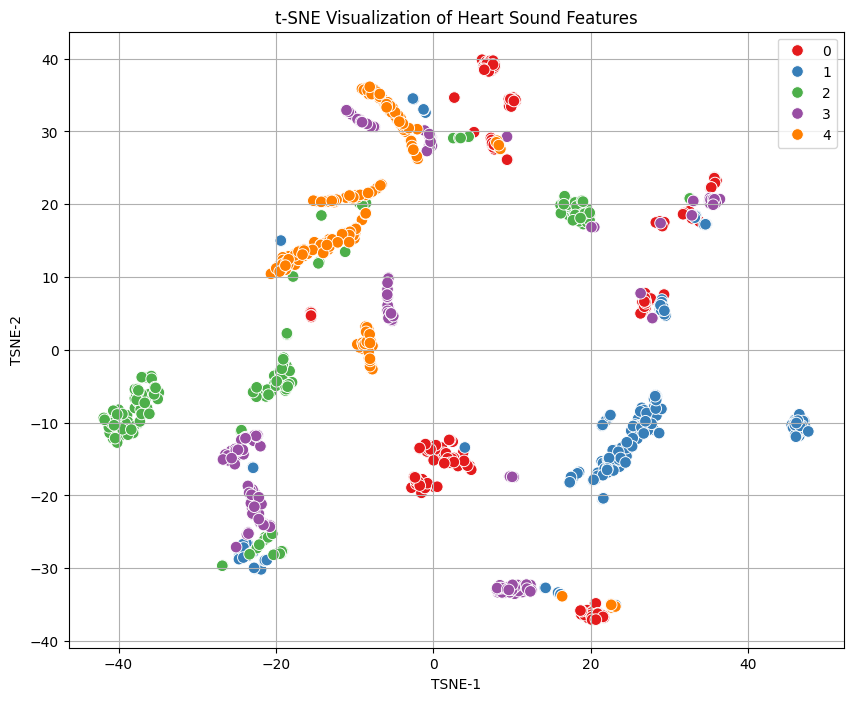

In [58]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# X = feature matrix (before LabelEncoder)
# y = original labels (AS, MR, MS, MVP, Normal)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X)

tsne_df = pd.DataFrame({
    "TSNE-1": X_tsne[:,0],
    "TSNE-2": X_tsne[:,1],
    "Label": y
})

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=tsne_df,
    x="TSNE-1",
    y="TSNE-2",
    hue="Label",
    palette="Set1",
    s=70
)

plt.title("t-SNE Visualization of Heart Sound Features")
plt.legend()
plt.grid(True)
plt.show()

In [59]:
!pip install umap-learn

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


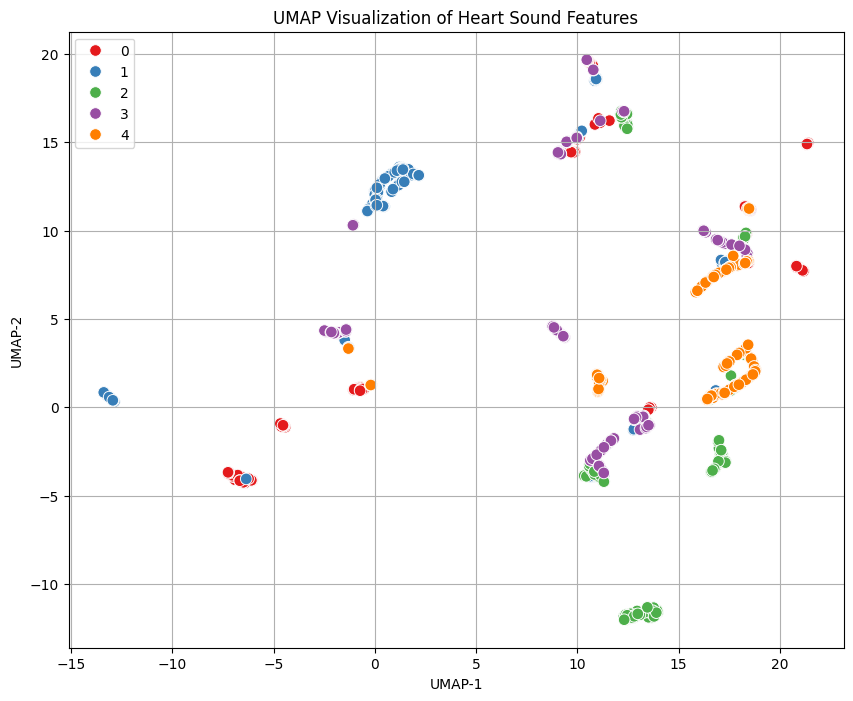

In [60]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

X_umap = reducer.fit_transform(X)

umap_df = pd.DataFrame({
    "UMAP-1": X_umap[:,0],
    "UMAP-2": X_umap[:,1],
    "Label": y
})

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=umap_df,
    x="UMAP-1",
    y="UMAP-2",
    hue="Label",
    palette="Set1",
    s=70
)

plt.title("UMAP Visualization of Heart Sound Features")
plt.legend()
plt.grid(True)
plt.show()

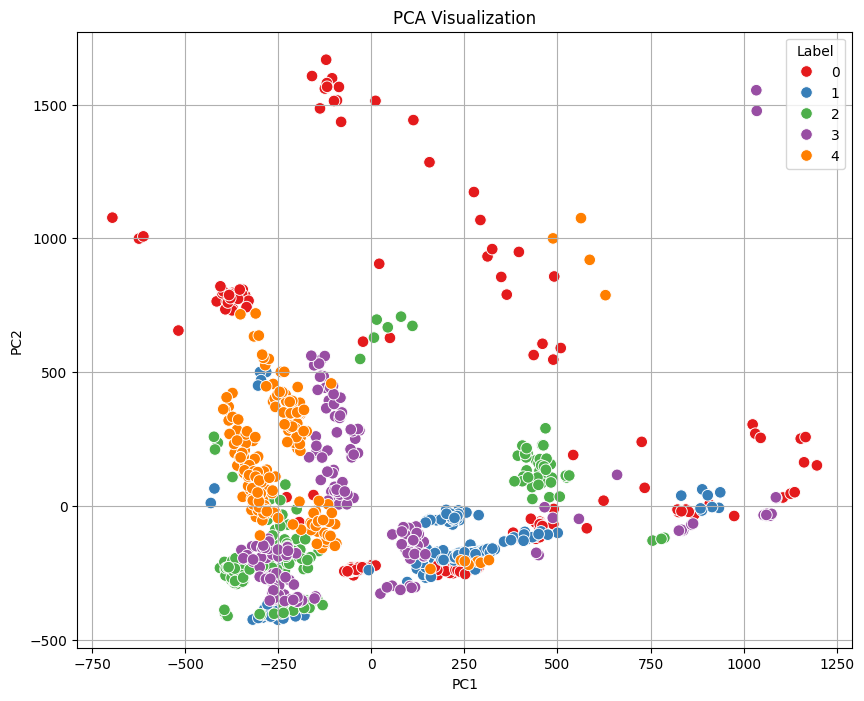

In [61]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Label": y
})

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Label",
    palette="Set1",
    s=70
)

plt.title("PCA Visualization")
plt.grid(True)
plt.show()

In [62]:
!pip install shap

In [63]:
best_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

best_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [55]:
import shap

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

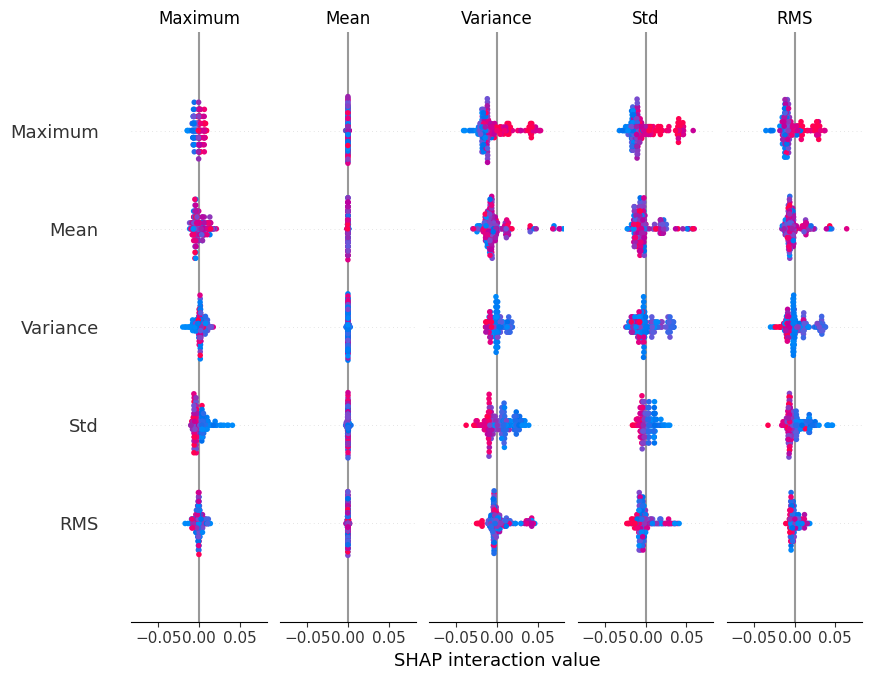

In [64]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

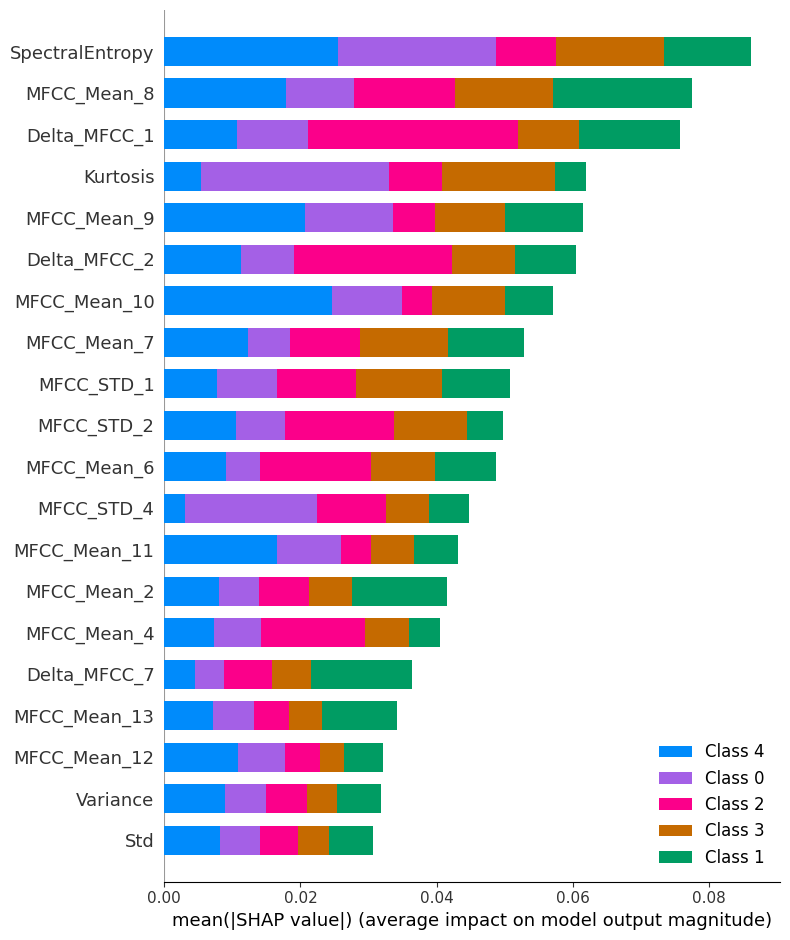

In [65]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns,
    plot_type="bar"
)

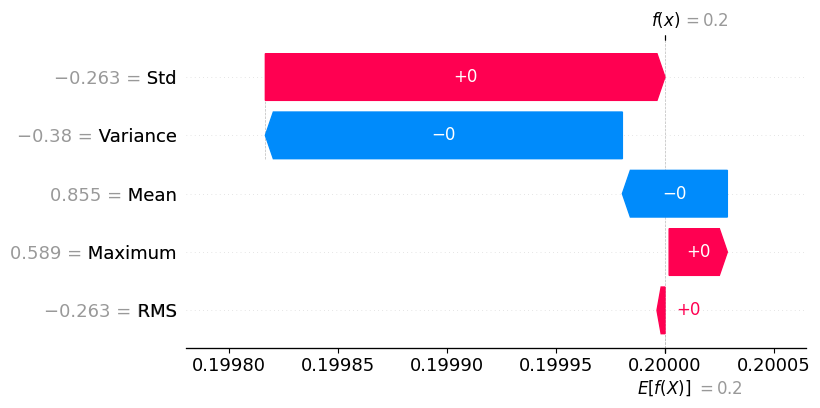

In [66]:
sample = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0][sample],
        base_values=explainer.expected_value[0],
        data=X_test[sample],
        feature_names=X.columns
    )
)